How many late days are you using for this assignment? 0

In [24]:
# Imports and pip installations (if needed)
%pip install pandas
import pandas as pd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Part 1: Load the dataset

In [2]:
# Load the given datasets
ckd_categorical = pd.read_csv("chronic_kidney_disease_categorical.csv")
ckd_numerical = pd.read_csv("chronic_kidney_disease_numerical.csv")
# Print the data
print(ckd_categorical)
print(ckd_numerical)

     unique_id   al   su       rbc        pc         pcc          ba  htn  \
0       224481  3.0  NaN       NaN       NaN  notpresent  notpresent  yes   
1       992643  0.0  0.0       NaN       NaN  notpresent  notpresent   no   
2       308740  1.0  0.0  abnormal  abnormal  notpresent  notpresent  yes   
3       450314  1.0  0.0       NaN    normal  notpresent  notpresent   no   
4       881763  0.0  0.0    normal    normal  notpresent  notpresent   no   
..         ...  ...  ...       ...       ...         ...         ...  ...   
425     769512  0.0  0.0    normal    normal  notpresent  notpresent   no   
426     872034  2.0  1.0  abnormal  abnormal  notpresent     present  yes   
427     643007  NaN  NaN       NaN    normal  notpresent  notpresent  yes   
428     840392  NaN  NaN       NaN       NaN  notpresent  notpresent  yes   
429     856244  0.0  0.0       NaN    normal  notpresent  notpresent  yes   

      dm  cad appet   pe  ane  Target  
0    yes   no  good  yes   no     c

# Part 2: Analyze the Dataset

Refer to this: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Explain what the each data is in your own words. What are the features and labels? Are the features in the given datasets : categorical, numerical or both? Give 3 examples of categorical and numerical columns each (if they exist)

Answer: The datasets consist of patient health data that can be used to predict chronic kidney disease. They include data for albumin, sugar, red blood cells, pus cell, pus cell clumps, bacteria, hypertension, diabetes mellitus, coronary artery disease, appetite, pedal edema, anemia, age, blood pressure, blood glucose random, blood urea, serum creatinine, sodium, potassium, hemoglobin, packed cell volume, white blood cell count, red blood cell count, and whether or not they have ckd. The features are attributes of a patient that are used to predict chronic kidney disease and the labels tell whether or not the patient has chronic kidney disease. Therefore the label is the Target column and the features are every other column except for the index and unique_id. The features in the ckd_categorical dataset are categorical and the features in the ckd_numerical dataset are numerical. Three categorical columns are rbc, pcc, and ba. Three numerical columns are age, bp, and bgr.

# Part 3: Data Preprocessing

A fundamental skill in Machine Learning is mastering the art of data cleaning and preprocessing. In this assignment, you will learn and apply essential data cleaning techniques to transform a raw dataset into a clean, ready-to-use form which you can use for regression or classification tasks. By the end of this assignment, you'll have a fully clean dataset and a solid foundation in preparing data for various machine learning models.

## Part 3.1 : Drop Duplicate rows

Let's start by checking if the given datasets have any duplicate rows (same Unique Id). Use pandas to identify and remove these duplicate rows from the given dataset

In [3]:
# For the numerical dataset, check if there are duplicate rows in the dataset. If yes, print total number of duplicate rows
dups_numerical = ckd_numerical.duplicated('unique_id')
print(sum(dups_numerical))
# Drop these duplicate rows
ckd_numerical_no_dups = ckd_numerical.drop_duplicates('unique_id')
# Repeat the same for categorical dataset. Print the duplicate rows and drop them
dups_categorical = ckd_categorical.duplicated('unique_id')
print(sum(dups_categorical))
ckd_categorical_no_dups = ckd_categorical.drop_duplicates('unique_id')


30
30


## Part 3.2: Combine two differents datasets

A good skill to have is to know how to combine 2 different datasets.

Are all the unique ids are present in both datasets? Why do you think so? If not, what do the rows that are missing from one of the datasets look like in the combined table?

Answer: No, not all the unique ids are present in both datasets since the datasets without duplicates have a different number of rows. If a row is missing from one of the datasets, it is not included in the combined dataset.

In [4]:
# Merge the two given numerical and categorical datasets based on their unique_ID.
combined_dataset = pd.merge(ckd_numerical_no_dups, ckd_categorical_no_dups, on='unique_id')
#Print the combined dataset
combined_dataset

,unique_id,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,...,pc,pcc,ba,htn,dm,cad,appet,pe,ane,Target
0,203694,38.0,80.0,99.0,19.0,0.5,147.0,3.5,13.6,44.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
1,938027,43.0,60.0,108.0,25.0,1.0,144.0,5.0,17.8,43.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
2,421471,37.0,60.0,111.0,35.0,0.8,135.0,4.1,16.2,50.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
3,764115,70.0,90.0,144.0,125.0,4.0,136.0,4.6,12.0,37.0,...,normal,notpresent,notpresent,yes,yes,no,poor,yes,no,ckd
4,240975,47.0,80.0,95.0,35.0,0.9,140.0,4.1,NaN,NaN,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,522912,56.0,80.0,165.0,55.0,1.8,NaN,NaN,13.5,40.0,...,normal,notpresent,notpresent,yes,yes,no,poor,yes,no,ckd
386,475200,64.0,100.0,163.0,54.0,7.2,140.0,4.6,7.9,26.0,...,abnormal,notpresent,present,yes,yes,no,good,yes,no,ckd
387,168242,48.0,60.0,112.0,44.0,1.2,142.0,4.9,14.5,44.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
388,474407,21.0,90.0,107.0,40.0,1.7,125.0,3.5,8.3,23.0,...,abnormal,present,present,no,no,no,good,no,yes,ckd


## Part 3.3: Rows with Missing values

Removing missing values from a dataset is important for classification because it ensures the model is trained on complete and accurate data, leading to better performance and reliable predictions. Incomplete data can introduce bias and errors, negatively impacting the model's effectiveness.

In [5]:
# Calculate the percentage of rows that contain atleast one missing value
missing_rows_percent = combined_dataset.isna().any(axis=1).sum() / combined_dataset.shape[0] * 100
# Print %
print(missing_rows_percent)
# Drop these rows from the dataset
removed_na_dataset = combined_dataset.dropna()
# Print the Dataset
removed_na_dataset

60.76923076923077


,unique_id,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,...,pc,pcc,ba,htn,dm,cad,appet,pe,ane,Target
0,203694,38.0,80.0,99.0,19.0,0.5,147.0,3.5,13.6,44.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
1,938027,43.0,60.0,108.0,25.0,1.0,144.0,5.0,17.8,43.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
2,421471,37.0,60.0,111.0,35.0,0.8,135.0,4.1,16.2,50.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
7,109053,64.0,60.0,106.0,27.0,0.7,150.0,3.3,14.4,42.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
13,349892,59.0,70.0,424.0,55.0,1.7,138.0,4.5,12.6,37.0,...,abnormal,notpresent,notpresent,yes,yes,yes,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,486397,20.0,70.0,123.0,44.0,1.0,135.0,3.8,14.6,44.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
381,462892,36.0,80.0,85.0,16.0,1.1,142.0,4.1,15.6,44.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
386,475200,64.0,100.0,163.0,54.0,7.2,140.0,4.6,7.9,26.0,...,abnormal,notpresent,present,yes,yes,no,good,yes,no,ckd
387,168242,48.0,60.0,112.0,44.0,1.2,142.0,4.9,14.5,44.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd


## Part 3.4: Sort the dataset according to the Labels

In [6]:
# Sort the dataset according to the values in 'Target' column. Make sure reset the indices after sorting
sorted_dataset = removed_na_dataset.sort_values('Target').reset_index(drop=True)
# Print the dataset
sorted_dataset

,unique_id,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,...,pc,pcc,ba,htn,dm,cad,appet,pe,ane,Target
0,474407,21.0,90.0,107.0,40.0,1.7,125.0,3.5,8.3,23.0,...,abnormal,present,present,no,no,no,good,no,yes,ckd
1,137148,73.0,100.0,295.0,90.0,5.6,140.0,2.9,9.2,30.0,...,abnormal,present,notpresent,yes,yes,yes,poor,no,no,ckd
2,484175,53.0,90.0,70.0,107.0,7.2,114.0,3.7,9.5,29.0,...,abnormal,present,notpresent,yes,yes,no,poor,no,yes,ckd
3,343710,61.0,80.0,173.0,148.0,3.9,135.0,5.2,7.7,24.0,...,abnormal,notpresent,notpresent,yes,yes,yes,poor,yes,yes,ckd
4,532520,60.0,90.0,105.0,53.0,2.3,136.0,5.2,11.1,33.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,647552,61.0,70.0,120.0,29.0,0.7,137.0,3.5,17.4,52.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
149,125587,37.0,60.0,109.0,47.0,1.1,141.0,4.9,15.0,48.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
150,614376,57.0,80.0,119.0,17.0,1.2,135.0,4.7,15.4,42.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
151,853426,41.0,70.0,125.0,38.0,0.6,140.0,5.0,16.8,41.0,...,normal,notpresent,notpresent,no,no,no,good,no,no,notckd


## Part 3.5: Encoding Categorical data

In this step, we identify and process the categorical columns in the sorted dataset. We map each unique value in these columns to separate "dummy" columns.

For example, the column 'rbc' will be transformed into two columns 'rbc_normal' and 'rbc_abnormal'. If a row's value in 'rbc' is 'normal', the 'rbc_normal' column will be set to 1 and 'rbc_abnormal' will be set to 0.


**Note: Find a correct pandas function to do this **

In [11]:
# Write code here
categorical_columns = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'Target']
encoded_categorical_dataset = pd.get_dummies(sorted_dataset, columns=categorical_columns, dtype=int)
# Print the dataset
encoded_categorical_dataset

,unique_id,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,...,cad_no,cad_yes,appet_good,appet_poor,pe_no,pe_yes,ane_no,ane_yes,Target_ckd,Target_notckd
0,474407,21.0,90.0,107.0,40.0,1.7,125.0,3.5,8.3,23.0,...,1,0,1,0,1,0,0,1,1,0
1,137148,73.0,100.0,295.0,90.0,5.6,140.0,2.9,9.2,30.0,...,0,1,0,1,1,0,1,0,1,0
2,484175,53.0,90.0,70.0,107.0,7.2,114.0,3.7,9.5,29.0,...,1,0,0,1,1,0,0,1,1,0
3,343710,61.0,80.0,173.0,148.0,3.9,135.0,5.2,7.7,24.0,...,0,1,0,1,0,1,0,1,1,0
4,532520,60.0,90.0,105.0,53.0,2.3,136.0,5.2,11.1,33.0,...,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,647552,61.0,70.0,120.0,29.0,0.7,137.0,3.5,17.4,52.0,...,1,0,1,0,1,0,1,0,0,1
149,125587,37.0,60.0,109.0,47.0,1.1,141.0,4.9,15.0,48.0,...,1,0,1,0,1,0,1,0,0,1
150,614376,57.0,80.0,119.0,17.0,1.2,135.0,4.7,15.4,42.0,...,1,0,1,0,1,0,1,0,0,1
151,853426,41.0,70.0,125.0,38.0,0.6,140.0,5.0,16.8,41.0,...,1,0,1,0,1,0,1,0,0,1


In the example we went through above, another solution is to have a single column for the binary variable. In the downstream modeling would this be equivalent? What effect would this have if the categorical variable could take more than 2 values? For example, let's say we have a categorical feature that is "type of condiment" that can take 5 separate values and we are trying to predict the rating of a particular sandwich.

Answer: In the downstream modeling, having a single column for the binary variable would be equivalent since 0 could represent one category (i.e. no) and 1 could represent the other (i.e. yes). If the categorical variable could take more than 2 values, using a single column by giving each value a number 0-n can be less effective because it introduces an implicit ordinal relationship that does not necessarily exist which could lead the model into misinterpreting the relationship or distance between the values.

## Part 3.6 : Remove Outliers from Numerical Columns

Outliers can disproportionately influence the fit of a regression model, potentially leading to a model that does not generalize well therefore it is important that we remove outliers from the numerical columns of the dataset.

For this dataset, we define an outlier to be 3 times the standard deviation from the mean. Drop these outliers from the dataset

In [13]:
# Remove outliers
numerical_columns = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
mean = encoded_categorical_dataset[numerical_columns].mean()
std = encoded_categorical_dataset[numerical_columns].std()
lower = mean - 3*std
upper = mean + 3*std
mask = ((encoded_categorical_dataset[numerical_columns] >= lower) & (encoded_categorical_dataset[numerical_columns] <= upper)).all(axis=1)
no_outliers_dataset = encoded_categorical_dataset[mask].reset_index(drop=True)
# Print the dataset
no_outliers_dataset

,unique_id,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,...,cad_no,cad_yes,appet_good,appet_poor,pe_no,pe_yes,ane_no,ane_yes,Target_ckd,Target_notckd
0,474407,21.0,90.0,107.0,40.0,1.7,125.0,3.5,8.3,23.0,...,1,0,1,0,1,0,0,1,1,0
1,137148,73.0,100.0,295.0,90.0,5.6,140.0,2.9,9.2,30.0,...,0,1,0,1,1,0,1,0,1,0
2,343710,61.0,80.0,173.0,148.0,3.9,135.0,5.2,7.7,24.0,...,0,1,0,1,0,1,0,1,1,0
3,532520,60.0,90.0,105.0,53.0,2.3,136.0,5.2,11.1,33.0,...,1,0,1,0,1,0,1,0,1,0
4,546225,46.0,60.0,163.0,92.0,3.3,141.0,4.0,9.8,28.0,...,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,647552,61.0,70.0,120.0,29.0,0.7,137.0,3.5,17.4,52.0,...,1,0,1,0,1,0,1,0,0,1
130,125587,37.0,60.0,109.0,47.0,1.1,141.0,4.9,15.0,48.0,...,1,0,1,0,1,0,1,0,0,1
131,614376,57.0,80.0,119.0,17.0,1.2,135.0,4.7,15.4,42.0,...,1,0,1,0,1,0,1,0,0,1
132,853426,41.0,70.0,125.0,38.0,0.6,140.0,5.0,16.8,41.0,...,1,0,1,0,1,0,1,0,0,1


## Part 3.7 : Normalize the Numerical Columns

Normalizing numerical attributes ensures that all features contribute equally to the model by scaling them to a consistent range, which improves model performance and convergence. It prevents features with larger scales from disproportionately influencing the model's learning process.

In [9]:
# Normalize the all Numerical Attributes in the dataset.
normalized_dataset = no_outliers_dataset.copy()
normalized_dataset[numerical_columns] = (no_outliers_dataset[numerical_columns] - no_outliers_dataset[numerical_columns].min()) / (no_outliers_dataset[numerical_columns].max() - no_outliers_dataset[numerical_columns].min())
# Print the dataset
normalized_dataset

,unique_id,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,...,cad_no,cad_yes,appet_good,appet_poor,pe_no,pe_yes,ane_no,ane_yes,Target_ckd,Target_notckd
0,474407,0.202703,0.75,0.158798,0.196078,0.160494,0.166667,0.171429,0.221311,0.184211,...,1,0,1,0,1,0,0,1,1,0
1,137148,0.905405,1.00,0.965665,0.522876,0.641975,0.666667,0.000000,0.295082,0.368421,...,0,1,0,1,1,0,1,0,1,0
2,343710,0.743243,0.50,0.442060,0.901961,0.432099,0.500000,0.657143,0.172131,0.210526,...,0,1,0,1,0,1,0,1,1,0
3,532520,0.729730,0.75,0.150215,0.281046,0.234568,0.533333,0.657143,0.450820,0.447368,...,1,0,1,0,1,0,1,0,1,0
4,546225,0.540541,0.00,0.399142,0.535948,0.358025,0.700000,0.314286,0.344262,0.315789,...,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,647552,0.743243,0.25,0.214592,0.124183,0.037037,0.566667,0.171429,0.967213,0.947368,...,1,0,1,0,1,0,1,0,0,1
130,125587,0.418919,0.00,0.167382,0.241830,0.086420,0.700000,0.571429,0.770492,0.842105,...,1,0,1,0,1,0,1,0,0,1
131,614376,0.689189,0.50,0.210300,0.045752,0.098765,0.500000,0.514286,0.803279,0.684211,...,1,0,1,0,1,0,1,0,0,1
132,853426,0.472973,0.25,0.236052,0.183007,0.024691,0.666667,0.600000,0.918033,0.657895,...,1,0,1,0,1,0,1,0,0,1


## Part 3.8: Remove Unnecessary columns

Are there any columns in this dataset which are not appropriate for modeling and predictions? Which column(s)? Justify their exclusion and remove them

Answer: The unique_id column is not appropriate for modeling and predictions because it is just an arbitrary number given to each row that has nothing to do with whether or not the patient has ckd. Keeping the column may lead to the model developing a relationship between unique_id and having ckd when in reality it is just a number meant to denote which patient is which, thus it must be removed.

In [32]:
#Remove that column
cleaned_dataset = normalized_dataset.drop(columns=['unique_id'])
# Print the dataset
cleaned_dataset

,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,...,cad_no,cad_yes,appet_good,appet_poor,pe_no,pe_yes,ane_no,ane_yes,Target_ckd,Target_notckd
0,0.202703,0.75,0.158798,0.196078,0.160494,0.166667,0.171429,0.221311,0.184211,0.653226,...,1,0,1,0,1,0,0,1,1,0
1,0.905405,1.00,0.965665,0.522876,0.641975,0.666667,0.000000,0.295082,0.368421,0.217742,...,0,1,0,1,1,0,1,0,1,0
2,0.743243,0.50,0.442060,0.901961,0.432099,0.500000,0.657143,0.172131,0.210526,0.395161,...,0,1,0,1,0,1,0,1,1,0
3,0.729730,0.75,0.150215,0.281046,0.234568,0.533333,0.657143,0.450820,0.447368,0.500000,...,1,0,1,0,1,0,1,0,1,0
4,0.540541,0.00,0.399142,0.535948,0.358025,0.700000,0.314286,0.344262,0.315789,0.830645,...,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,0.743243,0.25,0.214592,0.124183,0.037037,0.566667,0.171429,0.967213,0.947368,0.217742,...,1,0,1,0,1,0,1,0,0,1
130,0.418919,0.00,0.167382,0.241830,0.086420,0.700000,0.571429,0.770492,0.842105,0.217742,...,1,0,1,0,1,0,1,0,0,1
131,0.689189,0.50,0.210300,0.045752,0.098765,0.500000,0.514286,0.803279,0.684211,0.153226,...,1,0,1,0,1,0,1,0,0,1
132,0.472973,0.25,0.236052,0.183007,0.024691,0.666667,0.600000,0.918033,0.657895,0.161290,...,1,0,1,0,1,0,1,0,0,1


## Part 3.9: Export the Cleaned Data

Now that you've completed these cleaning steps you should have a pandas dataframe which is much cleaner and ready for modeling. Our final step is to save our work. Export the DataFrame to a two new formats: csv and json.

In [16]:
# Export the dataframe to a new csv file
cleaned_dataset.to_csv('cleaned_ckd_csv.csv', index=False)
# Export the dataframe to a new json file
cleaned_dataset.to_json('cleaned_ckd_json.json', orient='records')

# Part 4: Data conversions with Large Language Models

One powerful use case of ChatGPT (and other generative language models) is cleaning and transforming data. In some cases, these models can directly manipulate loosely structured data that you provide to them into a standard format. In the other cases, you can often prompt the model to create a conversion or extraction script for you in python or Pandas and then run it on your own. 

In this part of the assignment you will prompt 383GPT to explore these capabilities.

## Part 4.1 GPT Data Manipulation

Take the cleaned dataset that you created in part three and output the top 15 rows of that dataset. Then copy the terminal output, open 383gpt and ask it to convert that output to a markdown table. Paste that markdown table in the cell bellow

Paste here: 

| age     | bp   | bgr     | bu      | sc      | sod     | pot     | hemo    | pcv     | wbcc    | rbcc    | al | su | rbc_abnormal | rbc_normal | pc_abnormal | pc_normal | pcc_notpresent | pcc_present | ba_notpresent | ba_present | htn_no | htn_yes | dm_no | dm_yes | cad_no | cad_yes | appet_good | appet_poor | pe_no | pe_yes | ane_no | ane_yes | Target_ckd | Target_notckd |
|---------|------|---------|---------|---------|---------|---------|---------|---------|---------|---------|----|----|--------------|------------|-------------|-----------|----------------|-------------|---------------|------------|--------|---------|-------|--------|--------|---------|------------|------------|-------|--------|--------|---------|-------------|----------------|
| 0.202703 | 0.75 | 0.158798 | 0.196078 | 0.160494 | 0.166667 | 0.171429 | 0.221311 | 0.184211 | 0.653226 | 0.333333 | 4.0 | 0.0 | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 |
| 0.905405 | 1.00 | 0.965665 | 0.522876 | 0.641975 | 0.666667 | 0.000000 | 0.295082 | 0.368421 | 0.217742 | 0.153846 | 3.0 | 2.0 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 |
| 0.743243 | 0.50 | 0.442060 | 0.901961 | 0.432099 | 0.500000 | 0.657143 | 0.172131 | 0.210526 | 0.395161 | 0.153846 | 2.0 | 0.0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 |
| 0.729730 | 0.75 | 0.150215 | 0.281046 | 0.234568 | 0.533333 | 0.657143 | 0.450820 | 0.447368 | 0.500000 | 0.384615 | 2.0 | 0.0 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 |
| 0.540541 | 0.00 | 0.399142 | 0.535948 | 0.358025 | 0.700000 | 0.314286 | 0.344262 | 0.315789 | 0.830645 | 0.153846 | 1.0 | 0.0 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 |
| 0.675676 | 0.75 | 0.253219 | 0.633987 | 0.777778 | 0.366667 | 0.542857 | 0.286885 | 0.342105 | 0.169355 | 0.205128 | 2.0 | 0.0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 |
| 0.716216 | 0.50 | 1.000000 | 0.163399 | 0.111111 | 0.066667 | 0.171429 | 0.393443 | 0.500000 | 0.532258 | 0.435897 | 1.0 | 0.0 | 1 | 0 | 0 | 1 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 0 | 1 | 1 | 0 |
| 0.729730 | 0.00 | 0.935622 | 0.169935 | 0.160494 | 0.333333 | 0.028571 | 0.188525 | 0.236842 | 0.879032 | 0.102564 | 3.0 | 1.0 | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 |
| 0.837838 | 0.50 | 0.373391 | 0.522876 | 0.456790 | 0.333333 | 1.000000 | 0.000000 | 0.000000 | 0.540323 | 0.000000 | 3.0 | 2.0 | 0 | 1 | 1 | 0 | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 |
| 0.000000 | 0.00 | 0.103004 | 0.372549 | 0.074074 | 0.500000 | 0.571429 | 0.352459 | 0.368421 | 1.000000 | 0.564103 | 4.0 | 0.0 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 |
| 0.878378 | 0.00 | 0.206009 | 0.751634 | 0.604938 | 0.533333 | 0.571429 | 0.475410 | 0.500000 | 0.879032 | 0.435897 | 4.0 | 0.0 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 1 | 0 | 1 | 0 |
| 0.851351 | 0.25 | 0.618026 | 0.562092 | 0.728395 | 0.000000 | 0.285714 | 0.311475 | 0.315789 | 0.580645 | 0.179487 | 4.0 | 3.0 | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 |
| 0.878378 | 0.25 | 0.639485 | 0.470588 | 0.395062 | 0.433333 | 0.428571 | 0.393443 | 0.447368 | 0.104839 | 0.256410 | 3.0 | 0.0 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 0 |

** Caution: ** while language models can perform data conversions they also can * hallucinate * during this process, particularly for bigger datasets. Reflect on this below, how could you mitigate data conversion hallucinations from LLM conversions?

Despite asking for all 15 rows and asking in multiple different ways to include the last few rows, 383gpt would always stop early and not include the last few rows in the table. The data conversion hallucinations from LLMs can be mitigated by breaking it down into smaller chunks since it seems to work better with smaller amounts of data. The table also does not appear properly on github although it does in vscode. Here is a screenshot of it in vscode:

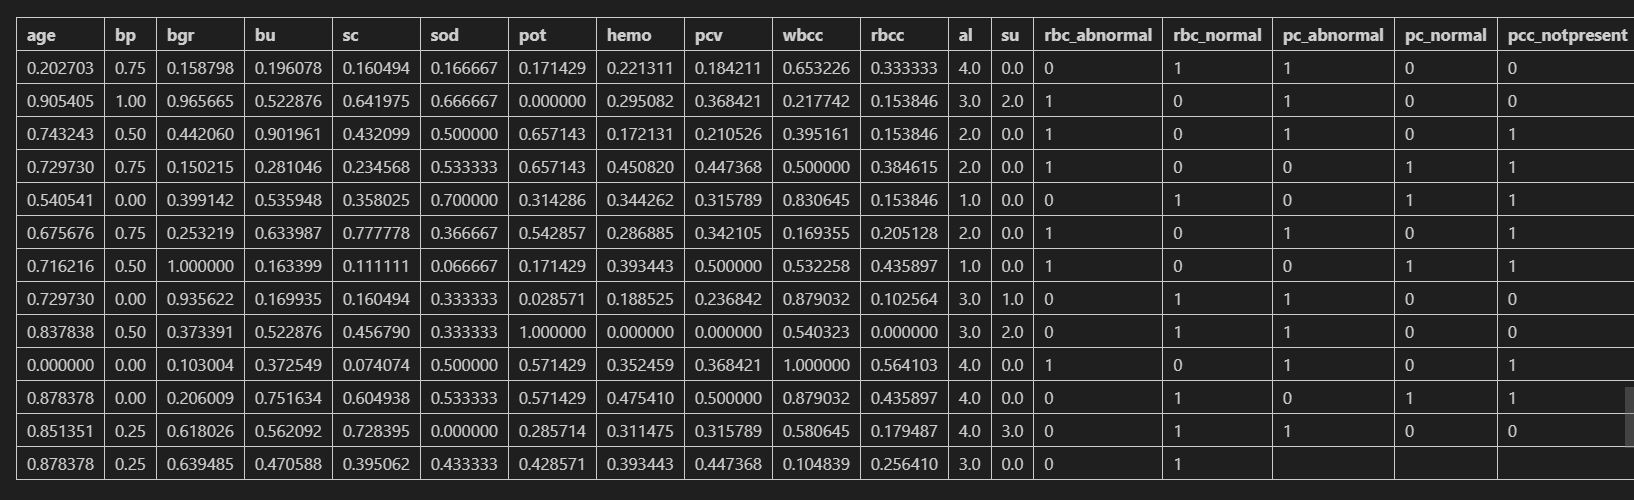

## Part 4.2 GPT Pandas Prompting

In this section, you will prompt 383GPT to write pandas code manipulations for you.

After working with this data for awhile, we realized we're starting to forget the meanings of the abbreviated column names. Let's ask 383GPT to fix this for us. First, navigate to the [UCI dataset overview](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease) and copy the abbrevation to name mapping. Then, go to 383GPT and instruct the LLM to provide you with a pandas script to apply this renaming to all the columns of your dataset. Paste that code below and make any adjustments necessary to run it in your notebook.

In [34]:
# Code to rename all the columns in the dataset\
# Define the mapping dictionary
rename_mapping = {
    'age': 'age',
    'bp': 'blood pressure',
    'sg': 'specific gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red blood cells',
    'pc': 'pus cell',
    'pcc': 'pus cell clumps',
    'ba': 'bacteria',
    'bgr': 'blood glucose random',
    'bu': 'blood urea',
    'sc': 'serum creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed cell volume',
    'wc': 'white blood cell count',
    'rc': 'red blood cell count',
    'htn': 'hypertension',
    'dm': 'diabetes mellitus',
    'cad': 'coronary artery disease',
    'appet': 'appetite',
    'pe': 'pedal edema',
    'ane': 'anemia',
    'class': 'class'
}

# Rename the columns using the mapping
renamed_dataset = cleaned_dataset.rename(columns=rename_mapping)

# Display the renamed DataFrame
print(renamed_dataset)

          age  blood pressure  blood glucose random  blood urea  \
0    0.202703            0.75              0.158798    0.196078   
1    0.905405            1.00              0.965665    0.522876   
2    0.743243            0.50              0.442060    0.901961   
3    0.729730            0.75              0.150215    0.281046   
4    0.540541            0.00              0.399142    0.535948   
..        ...             ...                   ...         ...   
129  0.743243            0.25              0.214592    0.124183   
130  0.418919            0.00              0.167382    0.241830   
131  0.689189            0.50              0.210300    0.045752   
132  0.472973            0.25              0.236052    0.183007   
133  0.662162            0.50              0.145923    0.117647   

     serum creatinine    sodium  potassium  hemoglobin  packed cell volume  \
0            0.160494  0.166667   0.171429    0.221311            0.184211   
1            0.641975  0.666667   0.000

## Part 4.3 Augmenting our skills with prompting

In addition, we can also use 383GPT to convert our data manipulation operations between different data manipulation languages and libraries. For example let's prompt 383GPT to convert the following SQL query to a pandas query.

**SQL Query**
```sql
SELECT Target, COUNT(*) AS count
FROM your_table_name
GROUP BY Target;
```

Prompt 383GPT to convert this to a pandas query. Run this query below, then describe what it does. (If you're not familiar with SQL that is okay you need to only comment on the final resulting output.)

In [36]:
# Converted SQL to Pandas code
# Group by 'Target' and count occurrences
result = cleaned_dataset.groupby('Target_ckd').size().reset_index(name='count')

# Display the result
print(result)

   Target_ckd  count
0           0    111
1           1     23


This code counts how many times each possible value of 'Target_ckd' appears in the 'Target_ckd' column and makes a new table to display that result.